In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/jegatheesanpriyanga/cancer-data/breast-cancer.csv


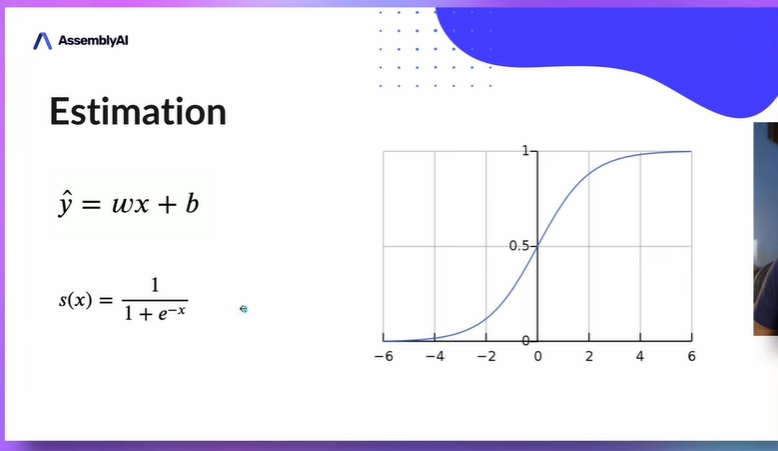

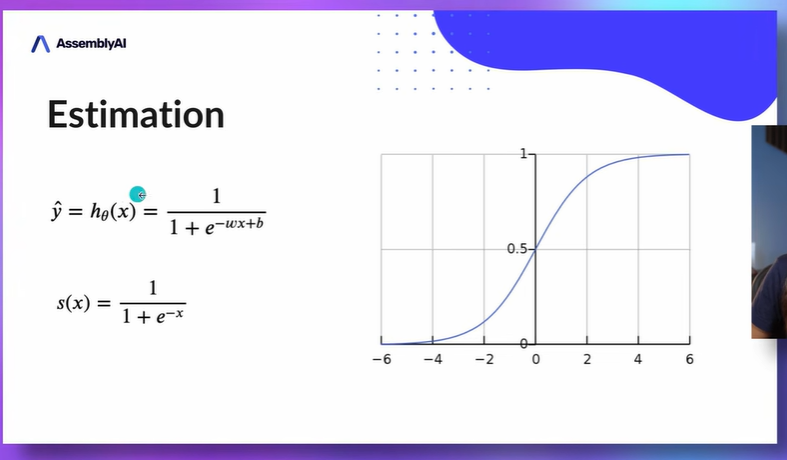

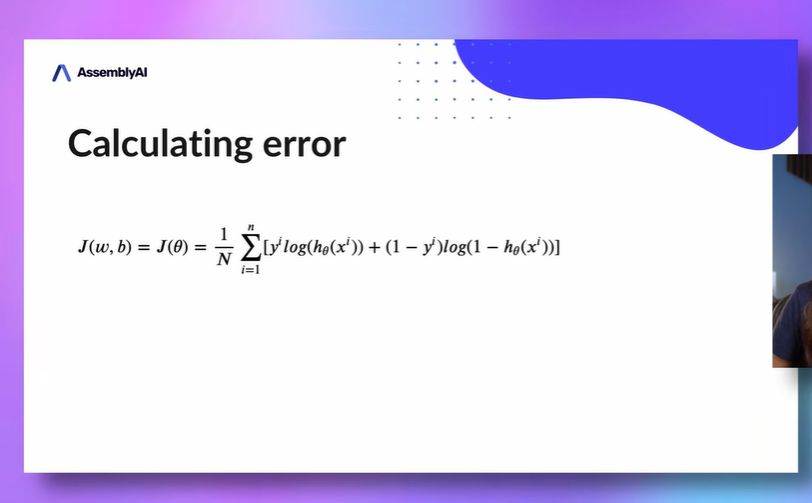

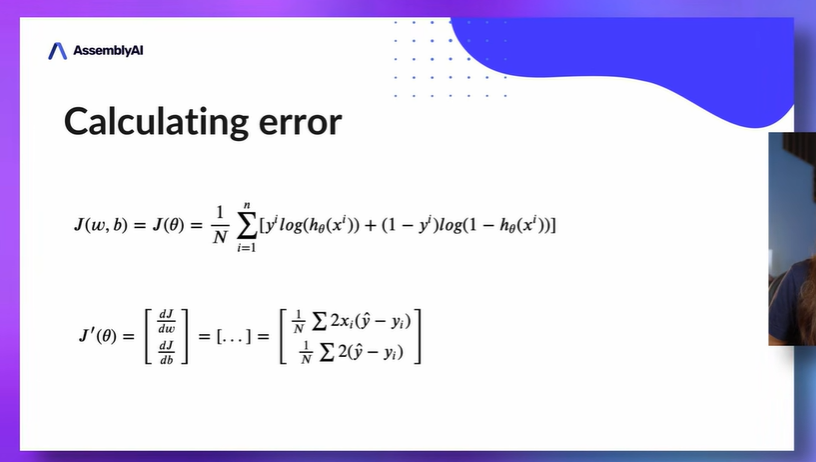

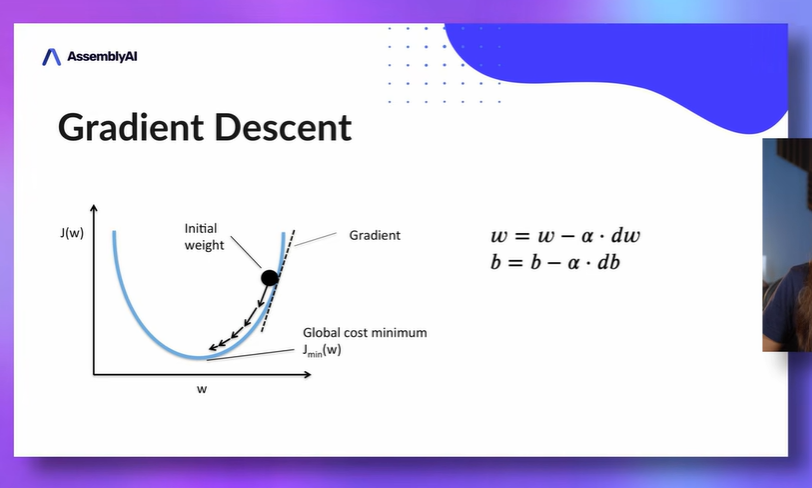

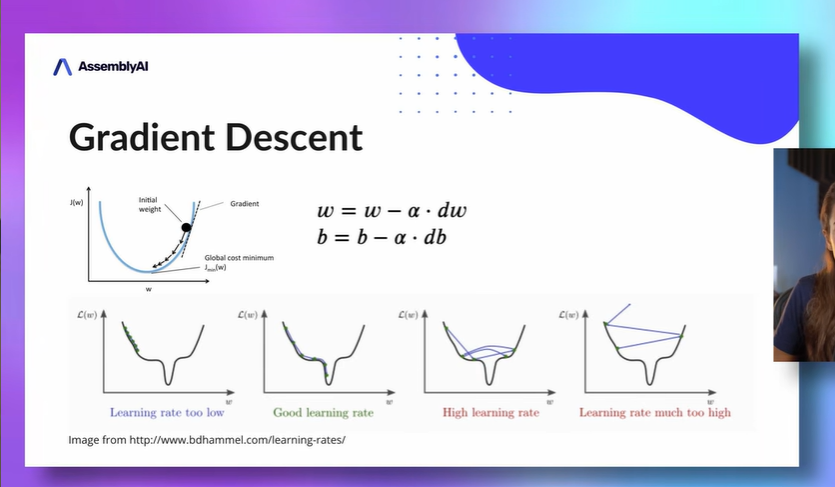

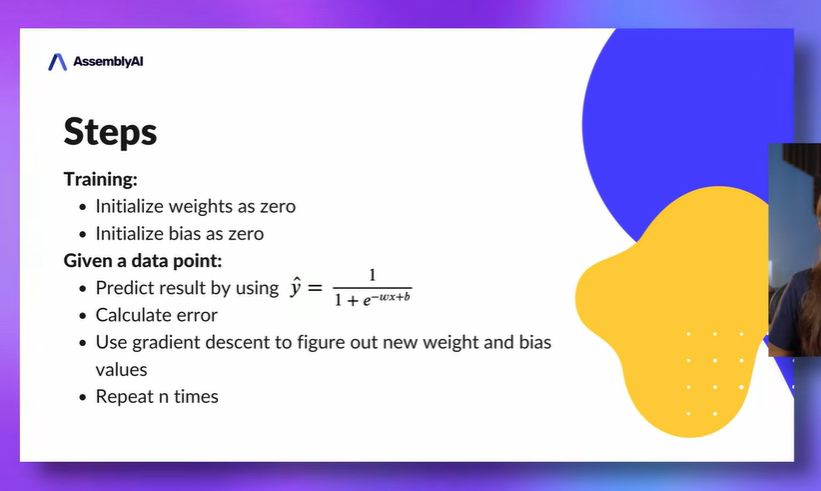

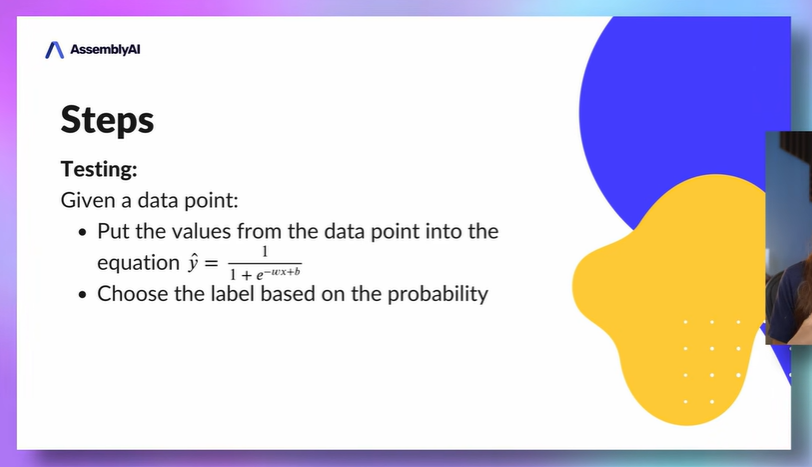



In [19]:
import numpy as np

In [52]:
def sigmoid(x):
    return 1/(1+np.exp(-x))

In [53]:
class LogisticRegression:
    def __init__(self, lr =0.001, n=1000):
        self.lr = lr
        self.n = n
        self.weights = None
        self.bias = None
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        for _ in range(self.n):
            linear_pred = np.dot(X, self.weights) + self.bias
            preds = sigmoid(linear_pred)
            dw = 1/n_samples * np.dot(X.T, (preds - y))
            db = 1/n_samples * np.sum(preds-y)    
            self.weights -= self.lr * dw 
            self.bias -= self.lr * db
    def predict(self,X):
        linear_pred = np.dot(X, self.weights) + self.bias
        y_preds = sigmoid(linear_pred)
        class_pred = [0 if y <= 0.5 else 1 for y in y_preds]
        return class_pred

In [54]:
df = pd.read_csv("/kaggle/input/datasets/jegatheesanpriyanga/cancer-data/breast-cancer.csv")

df["diagnosis"] = list(map(lambda x: 1 if x == "M" else 0, df["diagnosis"]))

In [55]:
print(df["diagnosis"][:30])

0     1
1     1
2     1
3     1
4     1
5     1
6     1
7     1
8     1
9     1
10    1
11    1
12    1
13    1
14    1
15    1
16    1
17    1
18    1
19    0
20    0
21    0
22    1
23    1
24    1
25    1
26    1
27    1
28    1
29    1
Name: diagnosis, dtype: int64


In [56]:
df.head

<bound method NDFrame.head of            id  diagnosis  radius_mean  texture_mean  perimeter_mean  \
0      842302          1        17.99         10.38          122.80   
1      842517          1        20.57         17.77          132.90   
2    84300903          1        19.69         21.25          130.00   
3    84348301          1        11.42         20.38           77.58   
4    84358402          1        20.29         14.34          135.10   
..        ...        ...          ...           ...             ...   
564    926424          1        21.56         22.39          142.00   
565    926682          1        20.13         28.25          131.20   
566    926954          1        16.60         28.08          108.30   
567    927241          1        20.60         29.33          140.10   
568     92751          0         7.76         24.54           47.92   

     area_mean  smoothness_mean  compactness_mean  concavity_mean  \
0       1001.0          0.11840           0.2776

In [57]:
from sklearn.model_selection import train_test_split
import pandas as pd


X = df.drop("diagnosis", axis = 1)

y = df.pop("diagnosis")

X_train, X_test,y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state = 500)

In [58]:
y_train.shape

(455,)

In [59]:
print(y_train.shape)
print(X_train.shape)

(455,)
(455, 31)


In [60]:
y_train[:3]

162    1
231    0
63     0
Name: diagnosis, dtype: int64

In [61]:
model = LogisticRegression(lr = 0.0001)

model.fit(X_train, y_train)


/tmp/ipykernel_58/4033946986.py:2: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-x))
/tmp/ipykernel_58/4033946986.py:2: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-x))
/tmp/ipykernel_58/4033946986.py:2: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-x))
/tmp/ipykernel_58/4033946986.py:2: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-x))
/tmp/ipykernel_58/4033946986.py:2: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-x))
/tmp/ipykernel_58/4033946986.py:2: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-x))
/tmp/ipykernel_58/4033946986.py:2: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-x))
/tmp/ipykernel_58/4033946986.py:2: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-x))
/tmp/ipykernel_58/4033946986.py:2: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-x))
/tmp/ipykernel_58/4033946986.py:2: RuntimeWarning: over

In [63]:
preds = model.predict(X_test)

preds[:3]

[1, 1, 1]

In [65]:
def accuracy(preds, y_test):
    return np.sum(preds == y_test)/ len(y_test)

In [66]:
print(accuracy(preds, y_test)*100)

30.701754385964914
